# Part IX — Statistics and Data Science
## Chapters 271–300

---

## What This Part Covers

Parts I–VIII gave you the mathematical infrastructure: logic, numbers, functions, geometry, vectors, linear algebra, calculus, and probability. Every one of those tools was built for a reason. Part IX is where you find out what that reason is.

Statistics and data science are the disciplines that connect mathematics to reality — specifically, to reality that is noisy, incomplete, and uncertain. You will learn how to:

- Describe and summarize data rigorously
- Reason about populations from samples
- Test hypotheses and quantify uncertainty
- Build, evaluate, and critique predictive models
- Understand the information content of data
- Implement core ML algorithms from mathematical first principles
- Scale computations to data that does not fit in memory

The final chapter (300) assembles everything into a complete, working end-to-end AI system.

---

## The Mental Shift

In Parts VII and VIII, the world was clean. Probability distributions were exact. Integrals converged. Derivatives existed.

In Part IX, the world is not clean. You have a CSV with missing values, duplicates, and inconsistent units. You have 10,000 samples from a process you cannot fully observe. You have a model that performs perfectly on training data and fails in production.

**The shift**: stop asking "what is the true answer?" and start asking "what is the best answer I can infer, and how confident should I be?"

This requires combining:
- **Probability** (Part VIII) — to model uncertainty formally
- **Linear algebra** (Part VI) — to represent and transform data efficiently
- **Calculus** (Part VII) — to optimize model parameters
- **Functions** (Part III) — to express hypotheses about relationships

Statistics is not a separate discipline from what came before. It is what all those tools look like when applied to real data.

---

## Map of Part IX

```
Data & Measurement (271)
        │
        ▼
Data Cleaning (272) ──────────────────────────────────────┐
        │                                                  │
        ▼                                                  ▼
Descriptive Statistics (273)                    Feature Engineering (291)
Visualization (274)                             Dimensionality Reduction (292)
Sampling (275)                                          │
        │                                               ▼
        ▼                                     Clustering (293)
Bias & Variance (276)                         Classification (294)
Hypothesis Testing (277)                               │
p-values (278)                                         ▼
Confidence Intervals (279)                   Neural Network Math Review (295)
Correlation (280)                            Optimization Methods (296)
        │                                    Large Scale Data (297)
        ▼                                             │
Regression (281)                                      ▼
Model Evaluation (282)                     Project: Full Pipeline (298)
Overfitting (283)                          Project: Mini ML Library (299)
Cross Validation (284)                              │
A/B Testing (285)                                   ▼
        │                              CAPSTONE: End-to-End AI (300)
        ▼
Bayesian Statistics (286)
Information Theory (287)
Entropy (288)
KL Divergence (289)
Mutual Information (290)
```

---

## Prerequisites from Prior Parts

| Concept | Where it appears in Part IX | Introduced |
|---|---|---|
| Probability distributions | ch277–279, ch286 | Part VIII |
| Expected value & variance | ch273, ch276 | ch249–ch250 |
| Bayes' theorem | ch286 | ch246 |
| Dot product, matrix multiply | ch280–281, ch292, ch294 | Parts V–VI |
| Gradient descent | ch281, ch295, ch296 | ch213 |
| SVD / PCA | ch292 | ch173–174 |
| Logarithms | ch287–290 | ch043 |
| Monte Carlo integration | ch285 | ch224 |
| Eigenvalues | ch292, ch295 | ch172 |

If any row in that table feels vague, return to the cited chapter before proceeding.

---

## Libraries Used in Part IX

Per the project rules: **implement from scratch first, validate with the library second.**

| Library | Purpose |
|---|---|
| `numpy` | Numerical arrays throughout |
| `matplotlib` | Visualization |
| `pandas` | Data loading and cleaning |
| `scipy.stats` | Validation of statistical tests |
| `sklearn` | Validation of ML models |

Every core algorithm in chapters 271–299 is implemented in NumPy first. The library call appears only to verify correctness.

---

## Motivating Problem: You Cannot Solve This Yet

The following cell generates a synthetic dataset and asks three questions. By the end of Part IX, you will be able to answer all three rigorously and implement the answers from scratch.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Dataset: 500 users, each with features and a label
n = 500
age          = rng.normal(35, 10, n).clip(18, 70)
session_time = 2.0 + 0.08 * age + rng.normal(0, 3, n)  # correlated with age
pages_viewed = rng.poisson(lam=4, size=n)
purchased    = ((0.3 * session_time + 0.1 * pages_viewed
                 - 0.02 * age + rng.normal(0, 1, n)) > 1.5).astype(int)

# Inject 30 missing values and 5 outliers
missing_idx = rng.choice(n, 30, replace=False)
session_time[missing_idx[:15]] = np.nan
pages_viewed = pages_viewed.astype(float)
pages_viewed[missing_idx[15:]] = np.nan
session_time[rng.choice(n, 5, replace=False)] = rng.uniform(50, 100, 5)

print(f"Dataset: {n} samples, {purchased.sum()} purchases ({purchased.mean():.1%} conversion)")
print(f"Missing session_time: {np.isnan(session_time).sum()}")
print(f"Missing pages_viewed: {np.isnan(pages_viewed).sum()}")
print()
print("Three questions you cannot yet answer rigorously:")
print()
print("Q1: Is session_time a statistically significant predictor of purchase?")
print("    (ch277–280: hypothesis testing, correlation)")
print()
print("Q2: Build a classifier. What is its true out-of-sample accuracy?")
print("    (ch281–284: regression, model evaluation, cross-validation)")
print()
print("Q3: Which feature carries the most information about the purchase label?")
print("    (ch287–290: information theory, mutual information)")

Dataset: 500 samples, 184 purchases (36.8% conversion)
Missing session_time: 15
Missing pages_viewed: 15

Three questions you cannot yet answer rigorously:

Q1: Is session_time a statistically significant predictor of purchase?
    (ch277–280: hypothesis testing, correlation)

Q2: Build a classifier. What is its true out-of-sample accuracy?
    (ch281–284: regression, model evaluation, cross-validation)

Q3: Which feature carries the most information about the purchase label?
    (ch287–290: information theory, mutual information)


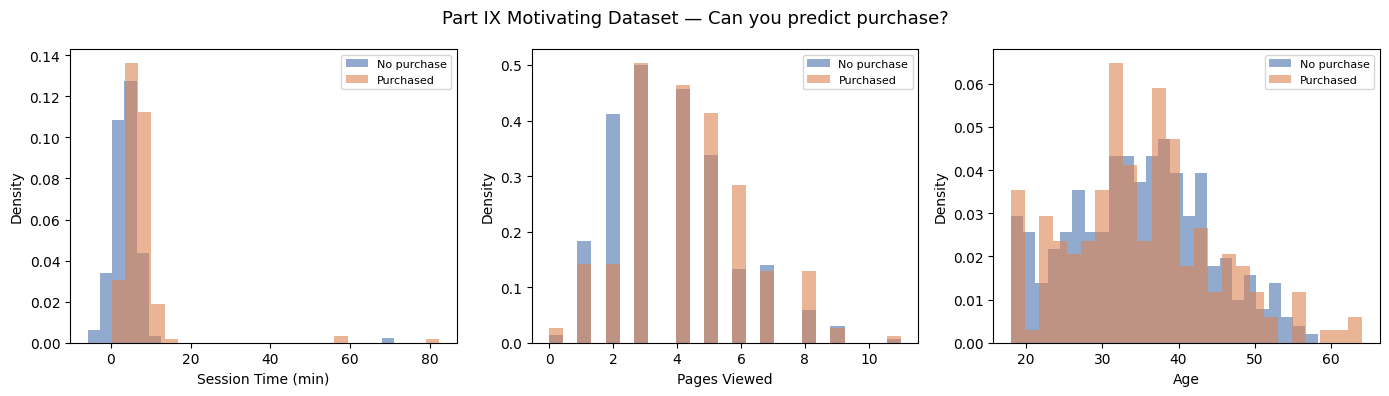

These distributions overlap. The signal is real but not obvious.
Part IX gives you the tools to extract it rigorously.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (feat, label) in zip(axes, [
    (session_time, 'Session Time (min)'),
    (pages_viewed,  'Pages Viewed'),
    (age,           'Age'),
]):
    valid = ~np.isnan(feat)
    for val, color, lbl in [(0, '#4C72B0', 'No purchase'), (1, '#DD8452', 'Purchased')]:
        mask = valid & (purchased == val)
        ax.hist(feat[mask], bins=25, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Part IX Motivating Dataset — Can you predict purchase?', fontsize=13)
plt.tight_layout()
plt.show()

print("These distributions overlap. The signal is real but not obvious.")
print("Part IX gives you the tools to extract it rigorously.")

---

## A Note on Rigor

Statistics is a field where sloppy thinking causes measurable real-world harm: bad drugs get approved, bad policies get enacted, bad models get deployed. The chapters ahead are not a survey. They are a systematic construction of the tools you need to think clearly under uncertainty.

Every formula has a derivation. Every algorithm has an implementation. Every claim can be verified computationally.

Proceed to **ch271 — Data and Measurement**.